#### Assignment 8: Supervised Learning Classification

#### Alyssa Iapalucci
#### Google Colab Link: https://colab.research.google.com/drive/10iJyuUR9a3FWlJ5hrfvwv7JK6xPwGS9f?usp=sharing

#### Github Link: https://github.com/alyssaiapalucci4/travel-classification-project

## Project Overview
This project focuses on predicting travel cost categories (Low, Medium, High) using machine learning classification models. The dataset contains travel-related features such as accommodation cost, transportation cost, traveler demographics, and trip details.

In [10]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [21]:
# Load Dataset
df = pd.read_csv("Travel details dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nShape of Dataset:")
print(df.shape)

Dataset Loaded Successfully

Columns:
1. Trip ID
2. Destination
3. Start date
4. End date
5. Duration (days)
6. Traveler name
7. Traveler age
8. Traveler gender
9. Traveler nationality
10. Accommodation type
11. Accommodation cost
12. Transportation type
13. Transportation cost

Shape of Dataset:
(139, 13)


In [12]:
# Data Preprocessing

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Convert cost columns to numeric
df["Accommodation cost"] = pd.to_numeric(df["Accommodation cost"], errors="coerce")
df["Transportation cost"] = pd.to_numeric(df["Transportation cost"], errors="coerce")

# Fill any missing cost values
df["Accommodation cost"] = df["Accommodation cost"].fillna(df["Accommodation cost"].median())
df["Transportation cost"] = df["Transportation cost"].fillna(df["Transportation cost"].median())

# Convert dates
df["Start date"] = pd.to_datetime(df["Start date"])
df["End date"] = pd.to_datetime(df["End date"])

# Extract useful date features
df["Start_Month"] = df["Start date"].dt.month
df["Trip_Length"] = (df["End date"] - df["Start date"]).dt.days

# Create Total Cost
df["Total_Cost"] = df["Accommodation cost"] + df["Transportation cost"]

# Create Cost Category (Target)
df["Cost_Category"] = pd.cut(
    df["Total_Cost"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Drop unnecessary columns
df = df.drop(["Trip ID", "Traveler name", "Start date", "End date"], axis=1)

# Encode categorical variables
label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values Before Cleaning:
Trip ID                 0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

Missing Values After Cleaning:
Destination             0
Duration (days)         0
Traveler age            0
Traveler gender         0
Traveler nationality    0
Accommodation type      0
Accommodation cost      0
Transportation type     0
Transportation cost     0
Start_Month             0
Trip_Length             0
Total_Cost              0
Cost_Category           0
dtype: int64


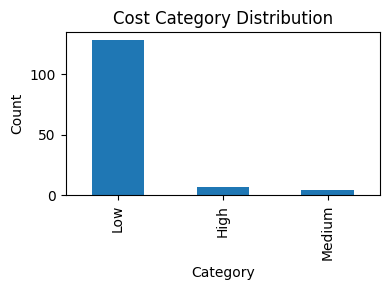

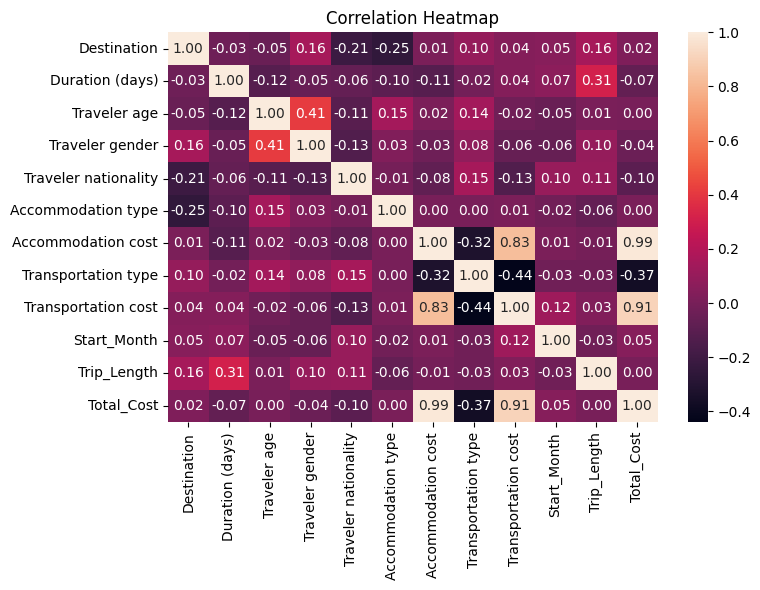

In [14]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Cost Category Distribution
plt.figure(figsize=(4,3))
df["Cost_Category"].value_counts().plot(kind="bar")
plt.title("Cost Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include=["number"]).corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [15]:
# SPLIT DATA

X = df.drop("Cost_Category", axis=1)
y = df["Cost_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# MODEL TRAINING

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Support Vector Machine
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)


In [17]:
# MODEL EVALUATION

def evaluate_model(name, y_test, y_pred):
    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

# Evaluate all models
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("SVM", y_test, svm_pred)
evaluate_model("KNN", y_test, knn_pred)


Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

SVM
Accuracy: 0.9285714285714286
Precision: 0.8622448979591837
Recall: 0.9285714285714286
F1 Score: 0.8941798941798941

KNN
Accuracy: 0.9642857142857143
Precision: 0.9298941798941798
Recall: 0.9642857142857143
F1 Score: 0.9467654986522911


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


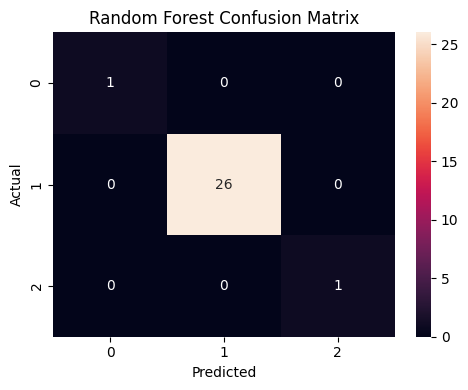

In [18]:
# MODEL INTERPRETATION

# Confusion Matrix for Best Model (Random Forest)
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [19]:
# DEPLOYMENT AND MONITORING

print("""
Deployment Plan:
- This model could be deployed into a travel budgeting app.
- Tools like Flask or FastAPI could be used.
- The trained model can be saved using joblib.

Monitoring Plan:
- Track model accuracy over time
- Retrain when performance drops
- Monitor unusual prediction patterns
""")


Deployment Plan:
- This model could be deployed into a travel budgeting app.
- Tools like Flask or FastAPI could be used.
- The trained model can be saved using joblib.

Monitoring Plan:
- Track model accuracy over time
- Retrain when performance drops
- Monitor unusual prediction patterns



In [20]:
# CONCLUSION

print("""
Conclusion:
This project used machine learning to classify travel costs into
Low, Medium, and High categories.

After cleaning the data, creating Total_Cost, and testing four
different classification models, Random Forest performed the best.

This project helped improve my understanding of preprocessing,
feature engineering, model training, and model evaluation.
""")


Conclusion:
This project used machine learning to classify travel costs into
Low, Medium, and High categories.

After cleaning the data, creating Total_Cost, and testing four
different classification models, Random Forest performed the best.

This project helped improve my understanding of preprocessing,
feature engineering, model training, and model evaluation.

